In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score,  recall_score, f1_score,classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')




In [2]:
df = pd.read_csv("../dataset/kidney_disease (1).csv")

In [3]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [4]:
df.tail()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd
399,399,58.0,80.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,53,6800,6.1,no,no,no,good,no,no,notckd


In [5]:
df.shape

(400, 26)

In [6]:
df.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [8]:
df.isnull().sum().sort_values(ascending=False)

rbc               152
rc                130
wc                105
pot                88
sod                87
pcv                70
pc                 65
hemo               52
su                 49
sg                 47
al                 46
bgr                44
bu                 19
sc                 17
bp                 12
age                 9
pcc                 4
ba                  4
dm                  2
htn                 2
cad                 2
appet               1
ane                 1
pe                  1
id                  0
classification      0
dtype: int64

In [9]:
df['classification'].value_counts()

classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64

In [10]:
# Drop id column
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)


# Strip whitespace from string values
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()


# Fix target stray values
df['classification'] = df['classification'].replace({'ckd\t': 'ckd'})

In [11]:
df['classification'].value_counts()

classification
ckd       250
notckd    150
Name: count, dtype: int64

In [12]:
# Typical numeric columns stored as objects in this dataset
numeric_obj_cols = ['pcv', 'wc', 'rc']
for col in numeric_obj_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [13]:
from sklearn.impute import SimpleImputer


# Separate cols
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(num_cols)
print(cat_cols)


# fill the numerical data by median & categorical data by mode
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')


# Apply
df_num = pd.DataFrame(num_imputer.fit_transform(df[num_cols]), columns=num_cols)
df_cat = pd.DataFrame(cat_imputer.fit_transform(df[cat_cols]), columns=cat_cols)


df_clean = pd.concat([df_num, df_cat], axis=1)


# Reorder to original
df_clean = df_clean[df.columns]

['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']


In [14]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             400 non-null    float64
 1   bp              400 non-null    float64
 2   sg              400 non-null    float64
 3   al              400 non-null    float64
 4   su              400 non-null    float64
 5   rbc             400 non-null    object 
 6   pc              400 non-null    object 
 7   pcc             400 non-null    object 
 8   ba              400 non-null    object 
 9   bgr             400 non-null    float64
 10  bu              400 non-null    float64
 11  sc              400 non-null    float64
 12  sod             400 non-null    float64
 13  pot             400 non-null    float64
 14  hemo            400 non-null    float64
 15  pcv             400 non-null    float64
 16  wc              400 non-null    float64
 17  rc              400 non-null    flo

In [15]:
# Label-encode all object columns (including target)
le = LabelEncoder()
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = le.fit_transform(df_clean[col])

In [16]:
df_clean

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,1,2,1,1,121.0,...,44.0,7800.0,5.2,2,2,1,0,1,1,0
1,7.0,50.0,1.020,4.0,0.0,1,2,1,1,121.0,...,38.0,6000.0,4.8,1,1,1,0,1,1,0
2,62.0,80.0,1.010,2.0,3.0,2,2,1,1,423.0,...,31.0,7500.0,4.8,1,2,1,2,1,2,0
3,48.0,70.0,1.005,4.0,0.0,2,0,2,1,117.0,...,32.0,6700.0,3.9,2,1,1,2,2,2,0
4,51.0,80.0,1.010,2.0,0.0,2,2,1,1,106.0,...,35.0,7300.0,4.6,1,1,1,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,2,2,1,1,140.0,...,47.0,6700.0,4.9,1,1,1,0,1,1,1
396,42.0,70.0,1.025,0.0,0.0,2,2,1,1,75.0,...,54.0,7800.0,6.2,1,1,1,0,1,1,1
397,12.0,80.0,1.020,0.0,0.0,2,2,1,1,100.0,...,49.0,6600.0,5.4,1,1,1,0,1,1,1
398,17.0,60.0,1.025,0.0,0.0,2,2,1,1,114.0,...,51.0,7200.0,5.9,1,1,1,0,1,1,1


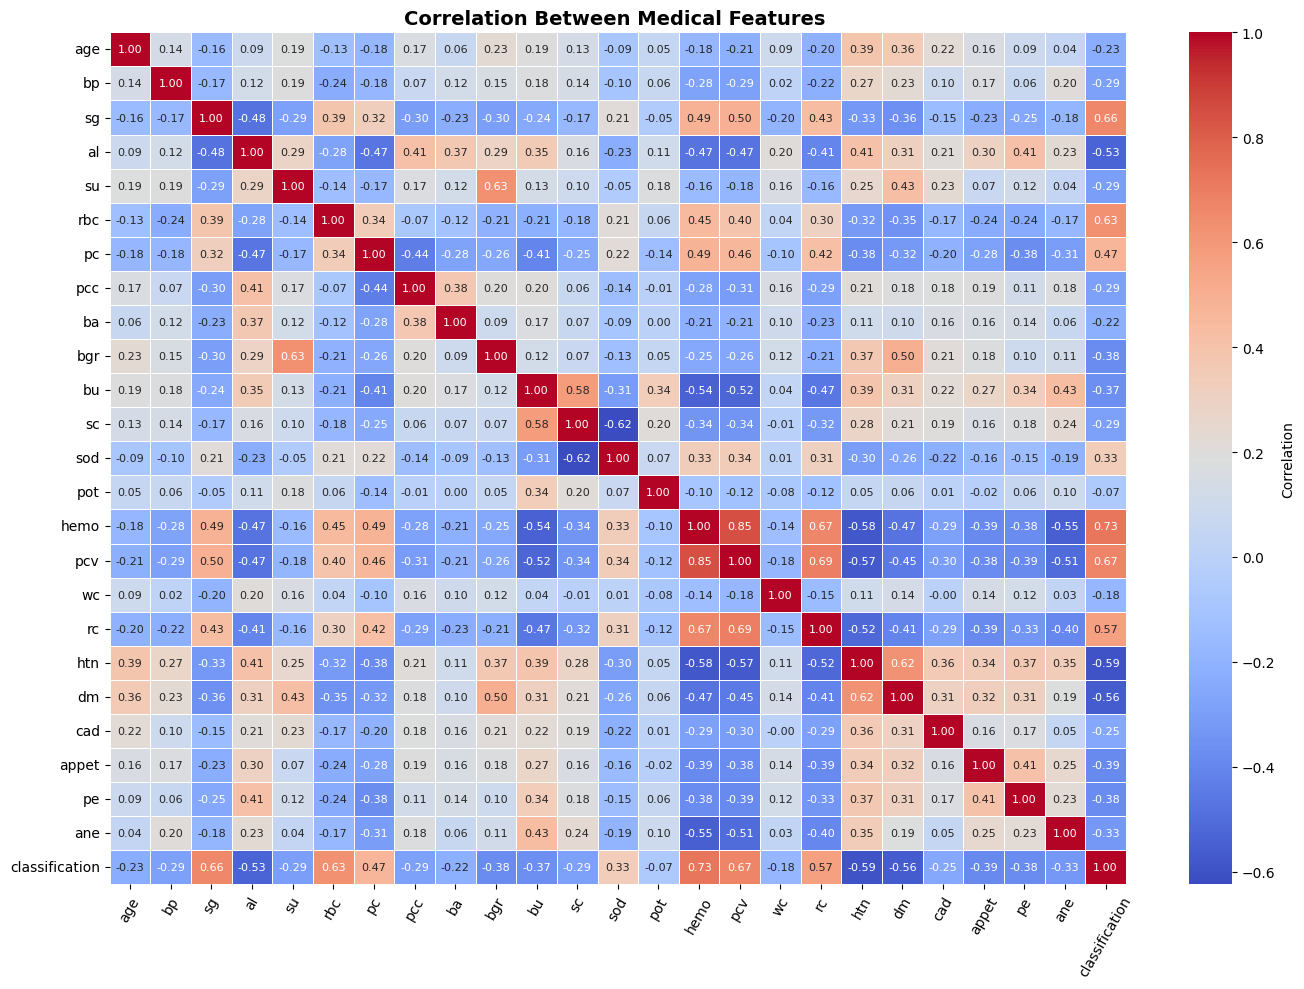

In [17]:
plt.figure(figsize=(14,10)) 
corr = df_clean.corr()

sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5,cbar_kws={'label': 'Correlation'},annot_kws={"size": 8})

plt.title("Correlation Between Medical Features ", fontsize=14, fontweight='bold')
plt.xticks(rotation=60)
plt.yticks()
plt.tight_layout()
plt.show()


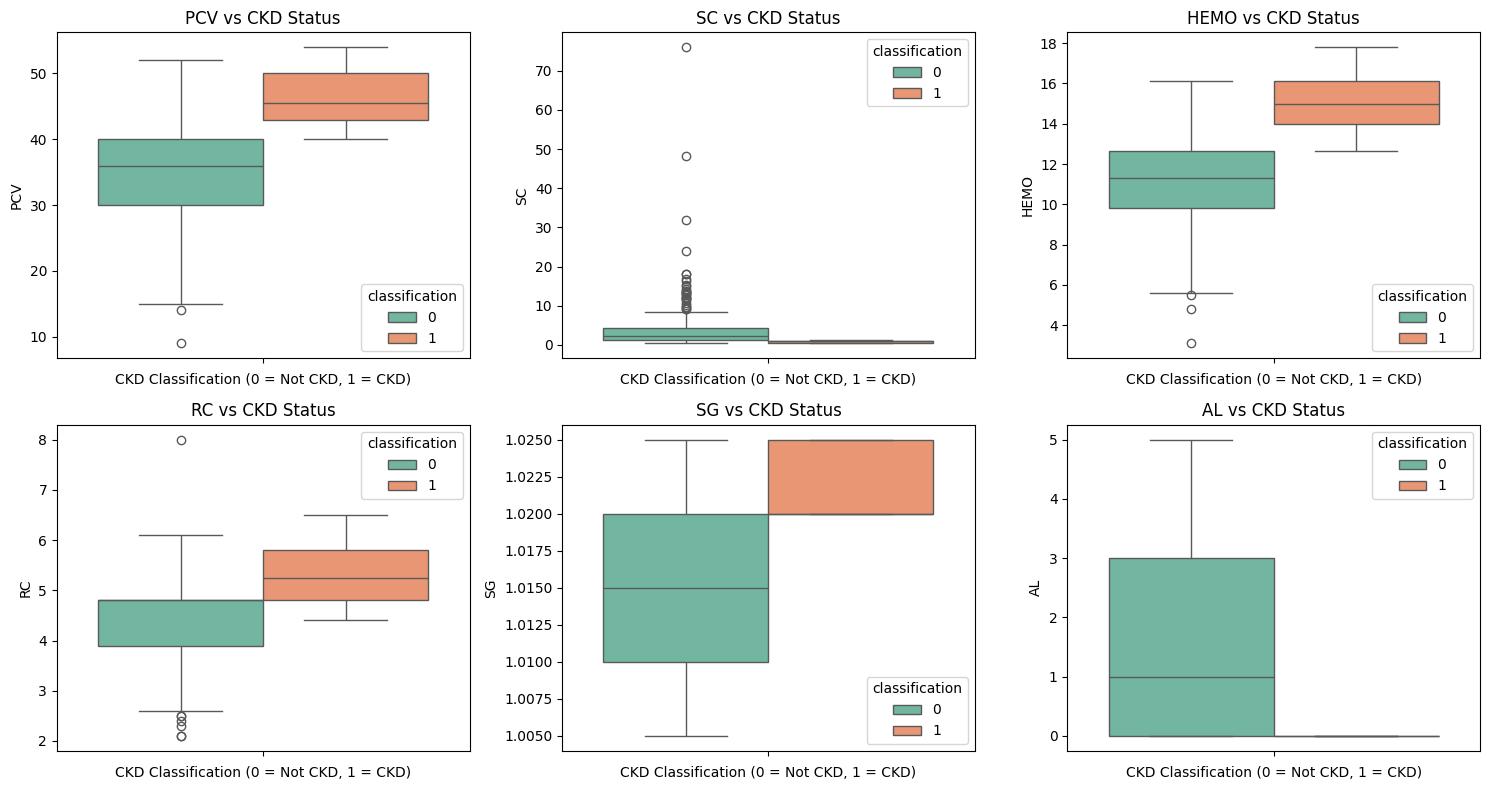

In [18]:
top_features = ['pcv', 'sc', 'hemo', 'rc', 'sg', 'al']

plt.figure(figsize=(15,8))
for i, col in enumerate(top_features):
    plt.subplot(2,3,i+1)
    sns.boxplot(data=df_clean, hue='classification', y=col, palette='Set2')
    plt.title(f"{col.upper()} vs CKD Status", fontsize=12)
    plt.xlabel("CKD Classification (0 = Not CKD, 1 = CKD)")
    plt.ylabel(col.upper())
plt.tight_layout()
plt.show()



In [19]:
X = df_clean.drop('classification', axis=1)
y = df_clean['classification']

In [20]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42, stratify=y)

In [21]:
#  Apply SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [22]:

print("Before Resampling:", y.value_counts().to_dict())
print("After Resampling:", y_train.value_counts().to_dict())

Before Resampling: {0: 250, 1: 150}
After Resampling: {1: 200, 0: 200}


In [23]:
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [24]:
print(len(X.columns))
print(X.columns.tolist())


24
['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


In [25]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}



 Model: Logistic Regression
Accuracy: 0.9875
Precision: 0.9677
Recall: 1.0000
F1 Score: 0.9836

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        50
           1       0.97      1.00      0.98        30

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



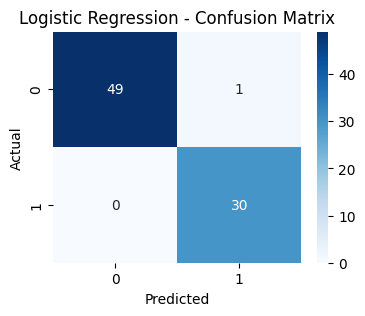


 Model: Decision Tree
Accuracy: 0.9750
Precision: 1.0000
Recall: 0.9333
F1 Score: 0.9655

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        50
           1       1.00      0.93      0.97        30

    accuracy                           0.97        80
   macro avg       0.98      0.97      0.97        80
weighted avg       0.98      0.97      0.97        80



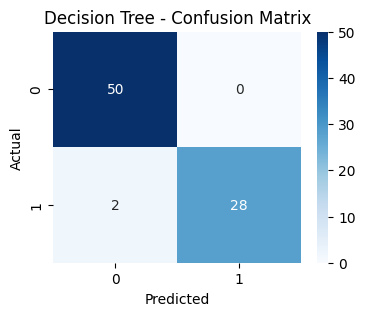


 Model: Random Forest
Accuracy: 0.9875
Precision: 1.0000
Recall: 0.9667
F1 Score: 0.9831

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        50
           1       1.00      0.97      0.98        30

    accuracy                           0.99        80
   macro avg       0.99      0.98      0.99        80
weighted avg       0.99      0.99      0.99        80



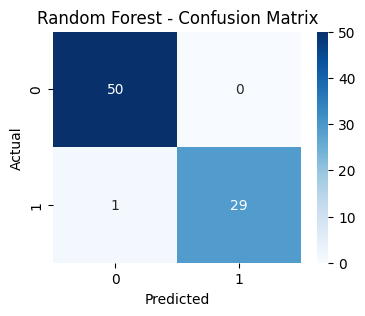


 Model: SVM
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        30

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



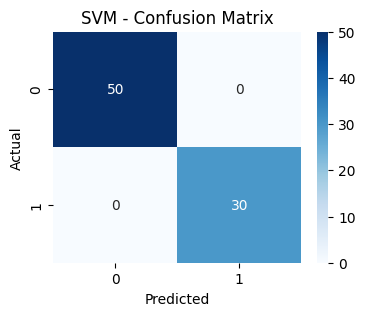


 Model: KNN
Accuracy: 0.9750
Precision: 0.9375
Recall: 1.0000
F1 Score: 0.9677

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98        50
           1       0.94      1.00      0.97        30

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80



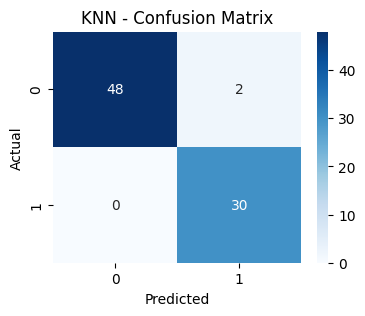


 Model: XGBoost
Accuracy: 0.9750
Precision: 1.0000
Recall: 0.9333
F1 Score: 0.9655

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        50
           1       1.00      0.93      0.97        30

    accuracy                           0.97        80
   macro avg       0.98      0.97      0.97        80
weighted avg       0.98      0.97      0.97        80



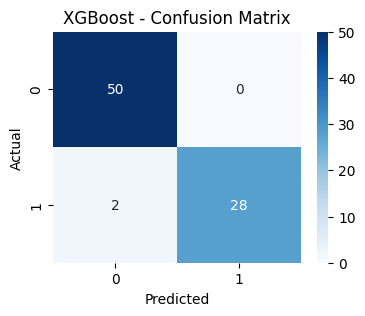



 Model Performance Comparison:
                 Model  Accuracy  Precision    Recall  F1 Score
3                  SVM    1.0000   1.000000  1.000000  1.000000
0  Logistic Regression    0.9875   0.967742  1.000000  0.983607
2        Random Forest    0.9875   1.000000  0.966667  0.983051
4                  KNN    0.9750   0.937500  1.000000  0.967742
1        Decision Tree    0.9750   1.000000  0.933333  0.965517
5              XGBoost    0.9750   1.000000  0.933333  0.965517


In [26]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, acc, prec, rec, f1])
    
    # Print metrics
    print(f"\n Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


#  Compare all models
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])
print("\n\n Model Performance Comparison:")
print(results_df.sort_values(by='F1 Score', ascending=False))

In [27]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    rf,
    params,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV F1 Score:", grid.best_score_)

best_rf = grid.best_estimator_

y_pred_train = best_rf.predict(X_train)
y_pred_test = best_rf.predict(X_test)

print("\nTrain Report:\n")
print(classification_report(y_train, y_pred_train))

print("\nTest Report:\n")
print(classification_report(y_test, y_pred_test))

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1 Score: 0.9974683544303797

Train Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400


Test Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        50
           1       1.00      0.97      0.98        30

    accuracy                           0.99        80
   macro avg       0.99      0.98      0.99        80
weighted avg       0.99      0.99      0.99        80



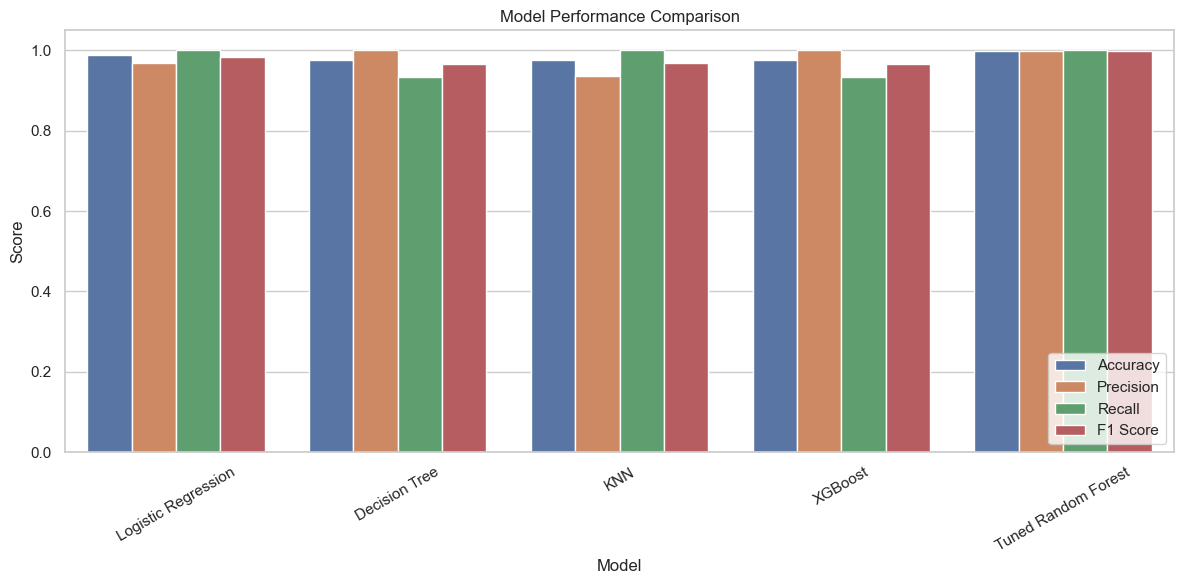

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Create a DataFrame with your model performance
data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'KNN', 'XGBoost', 'Tuned Random Forest'],
    'Accuracy': [0.9875, 0.9750, 0.9750, 0.9750, 0.999],
    'Precision': [0.967742, 1.0000, 0.9375, 1.0000, 0.999],
    'Recall': [1.0000, 0.933333, 1.0000, 0.933333, 0.9999],
    'F1 Score': [0.983607, 0.965517, 0.967742, 0.965517, 0.9997]
}

df = pd.DataFrame(data)

# Set style
sns.set(style="whitegrid")

# Plot grouped bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
df_melted = df.melt(id_vars='Model', value_vars=metrics, var_name='Metric', value_name='Score')

plt.figure(figsize=(12,6))
sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted)
plt.title('Model Performance Comparison')
plt.ylim(0, 1.05)
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


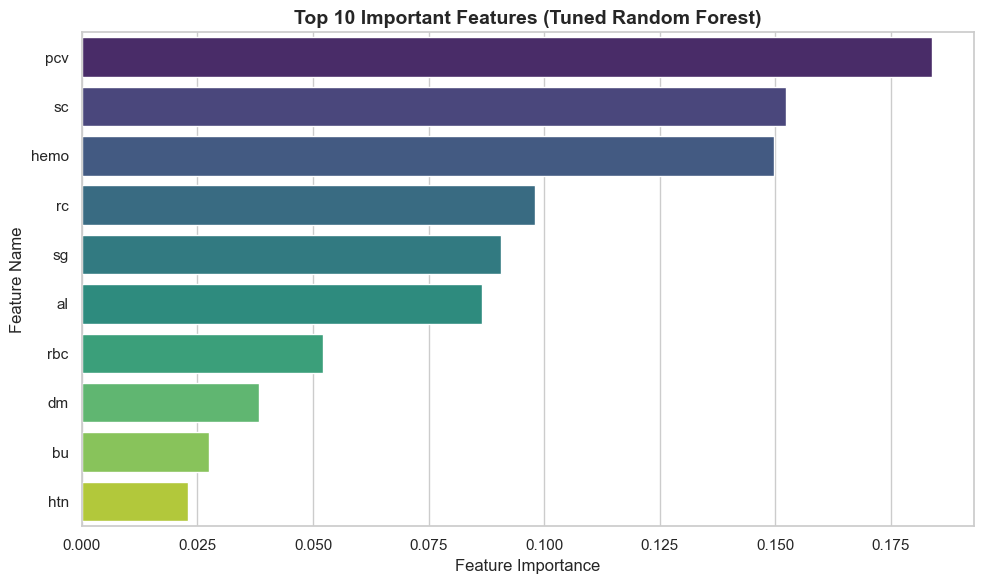

In [29]:
# Create a DataFrame for visualization

importances = best_rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title("Top 10 Important Features (Tuned Random Forest)", fontsize=14, fontweight='bold')
plt.xlabel("Feature Importance")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()

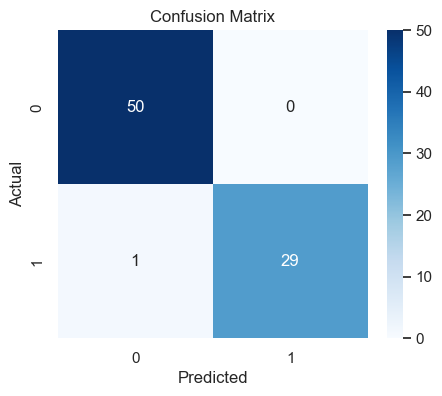

In [35]:
# Predictions
y_pred = best_rf.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [30]:
import joblib
fileName_kidney = "../saved_models/kidney.joblib"

In [31]:
joblib.dump(best_rf,fileName_kidney)
joblib.dump(scaler, "../saved_models/kidney_scaler.joblib")

['../saved_models/kidney_scaler.joblib']

In [32]:


# Load model and scaler
model = joblib.load("../saved_models/kidney.joblib")
scaler = joblib.load("../saved_models/kidney_scaler.joblib")

# Feature order used during training
feature_list = [
    'age', 'bp', 'sg', 'al', 'su',
    'rbc', 'pc', 'pcc', 'ba',
    'bgr', 'bu', 'sc', 'sod', 'pot',
    'hemo', 'pcv', 'wc', 'rc',
    'htn', 'dm', 'cad', 'appet', 'pe', 'ane'
]


input_data = np.array([[
    48, 80, 1.020, 1, 0,
    1, 1, 0, 0,
    121, 36, 1.2, 135, 4.5,
    15.4, 44, 7800, 5.2,
    1, 0, 0, 1, 0, 0
]])

# Convert to dataframe for scaler
input_df = pd.DataFrame(input_data, columns=feature_list)

# Scale NUMERIC columns only
num_cols = ['age','bp','sg','al','su','bgr','bu','sc','sod','pot','hemo','pcv','wc','rc']

input_df[num_cols] = scaler.transform(input_df[num_cols])

# Predict
prediction = best_rf.predict(input_df)

print("Prediction:", prediction)
if prediction[0] == 0:
    print("No CKD")
else:
    print("CKD Detected")


Prediction: [0]
No CKD
